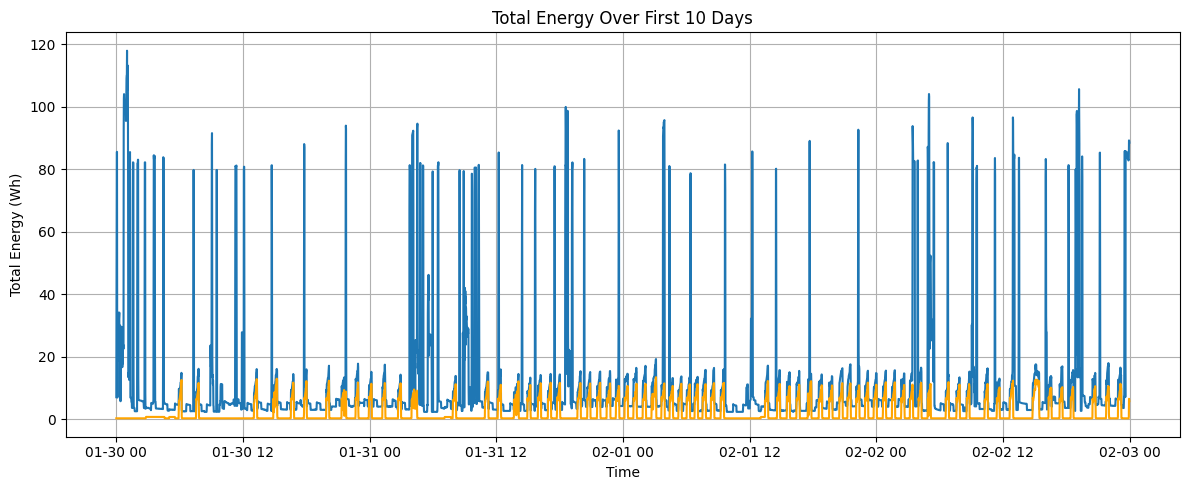

,Outdoor_Temp_C,Indoor_Temperature_C,Indoor_RH_Percent,HVAC_Energy_usage_KWh,total_energy,pump_energy,hvac_energy
timestamps,,,,,,,
2022-08-14 13:35:00,25.67,26.666667,43.00,0.000090,2.692948,0.0900,0.0903
2022-08-14 13:36:00,25.83,26.666667,43.00,0.000089,2.687115,0.0892,0.0894
2022-08-14 13:37:00,25.89,26.666667,43.00,0.000090,2.679060,0.0894,0.0897
2022-08-14 13:38:00,25.94,26.666667,43.00,0.000089,2.667116,0.0889,0.0892
2022-08-14 13:39:00,26.00,26.666667,43.00,0.000091,2.658783,0.0903,0.0906
...,...,...,...,...,...,...,...
2022-08-14 15:10:00,26.00,25.933333,44.90,0.000089,2.716558,0.0889,0.0894
2022-08-14 15:11:00,25.89,25.911111,44.95,0.000089,2.713780,0.0892,0.0894
2022-08-14 15:12:00,25.83,25.888889,45.00,0.000091,2.702947,0.0903,0.0906


In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt

folder_path = 'datasets/retrofit'

dfs = []

for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        df = df[['Timestamp', 'Outdoor_Temp_C', 'Indoor_Temperature_C', 'Indoor_RH_Percent', 'First_Floor_Heat_Pump_KWh', 'Overall_Energy_usage_KWh', 'HVAC_Energy_usage_KWh']]
        df['total_energy'] = df['Overall_Energy_usage_KWh'] * 1000
        df['pump_energy'] = df['First_Floor_Heat_Pump_KWh'] * 1000
        df['hvac_energy'] = df['HVAC_Energy_usage_KWh'] * 1000
        df['timestamps'] = pd.to_datetime(df['Timestamp'])
        
        df.drop(columns=['Overall_Energy_usage_KWh', 'First_Floor_Heat_Pump_KWh', 'Timestamp'], inplace=True)
        df.set_index('timestamps', inplace=True)
        df.sort_index(inplace=True)
        dfs.append(df)

df = dfs[0]
start_date = '2023-01-30'
end_date = '2023-02-02'
df_10days = df.loc[start_date:end_date]
plt.figure(figsize=(12, 5))
plt.plot(df_10days.index, df_10days['total_energy'], label='Total Energy')
plt.plot(df_10days.index, df_10days['hvac_energy'], label='HVAC Usage', color='orange')
plt.title('Total Energy Over First 10 Days')
plt.xlabel('Time')
plt.ylabel('Total Energy (Wh)')
plt.grid(True)
plt.tight_layout()
plt.show()

dfs[0].head(100)

In [ ]:
# resampled = dfs[0].resample('15min').agg({
#     'total_energy': 'sum',
#     'hvac_energy': 'sum',
#     'pump_energy': 'sum',
#     'Outdoor_Temp_C': 'mean',
#     'Indoor_Temperature_C': 'mean',
#     'Indoor_RH_Percent': 'mean',
# })
import os

agg_rules = {
    'total_energy': 'sum',
    'hvac_energy': 'sum',
    'pump_energy': 'sum',
    'Outdoor_Temp_C': 'mean',
    'Indoor_Temperature_C': 'mean',
    'Indoor_RH_Percent': 'mean',
}
dfs_resampled = []
for index, df in enumerate(dfs):    
    # if 'timestamps' in df.columns:
    #     df['timestamps'] = pd.to_datetime(df['timestamps'])
    #     df.set_index('timestamps', inplace=True)
    # df.sort_index(inplace=True)

    valid_rules = {col: agg_rules[col] for col in df.columns if col in agg_rules}

    df_resampled = df.resample('15T').agg(valid_rules)

    dfs_resampled.append(df_resampled)
    df_resampled.to_csv(os.path.join('datasets/retrofit', f'resampled_{index}.csv'))


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16164\3468904334.py:28: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = df.resample('15T').agg(valid_rules)


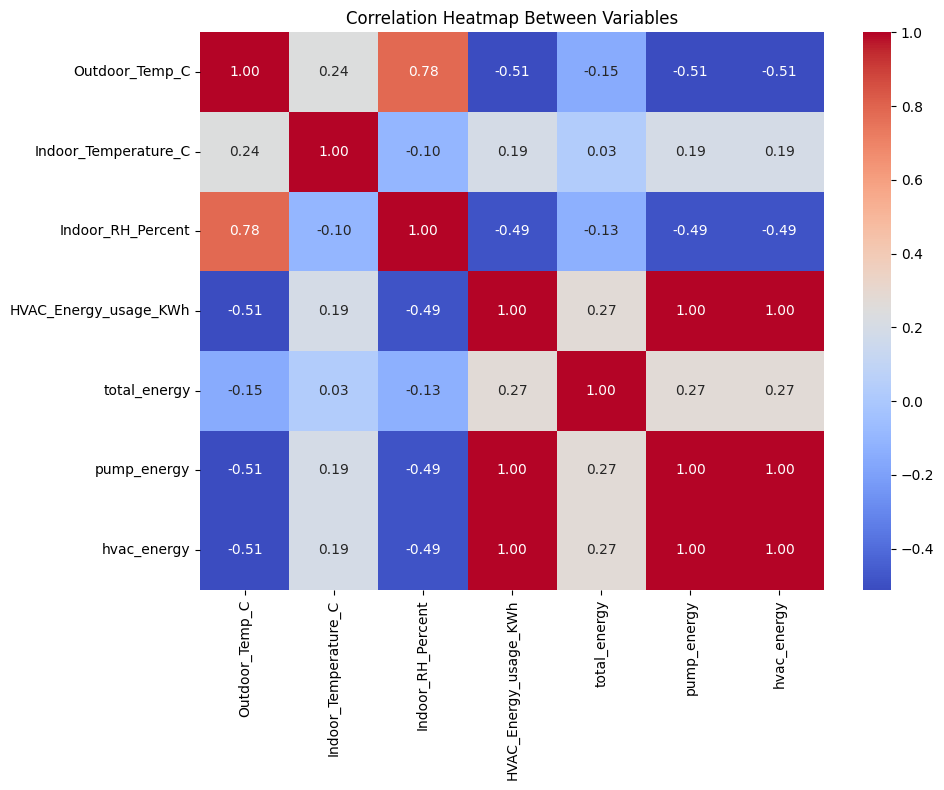

In [27]:
import seaborn as sns
corr = dfs[7].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap Between Variables')
plt.tight_layout()
plt.show()